In [1]:
import pandas as pd

from data.data_preprocessing import retrive_and_extract_relevant_data_values, generate_loaders_and_benchmark

In [2]:
df = pd.read_csv(
    "data\\OMXS22_raw_features.csv",
    parse_dates=["Date"],
    index_col="Date"
)


feature_cols = ["Close","Volume",
                "MarketCap","Weight",
                "Return","LogReturn","WeightedRet",
                "SMA20","EMA20","RSI14","ReturnVola20"]

chosen_ticker = "KINV-B.ST"

In [3]:
data_values, dataframe = retrive_and_extract_relevant_data_values(df=df, feature_cols=feature_cols, chosen_ticker=chosen_ticker, no_plotting=True)


Shape dataset (6409, 11)
means:  Close           8.036797e+01
Volume          1.087093e+06
MarketCap       1.954685e+10
Weight          6.289315e-03
Return          4.417263e-04
LogReturn       1.723115e-04
WeightedRet     4.306955e-06
SMA20           8.029539e+01
EMA20           8.029467e+01
RSI14           5.211280e+01
ReturnVola20    2.049862e-02
dtype: float64
stds:  Close           7.186329e+01
Volume          9.459844e+05
MarketCap       1.747837e+10
Weight          3.087590e-03
Return          2.315582e-02
LogReturn       2.325378e-02
WeightedRet     1.423583e-04
SMA20           7.175884e+01
EMA20           7.168856e+01
RSI14           1.325365e+01
ReturnVola20    1.071267e-02
dtype: float64


In [4]:
data_values = data_values
window_step_length = 100
window_size = 100
num_test_points = 200

horizon = 3 #3 is good
target_idx = 0

n_features = data_values.shape[1]

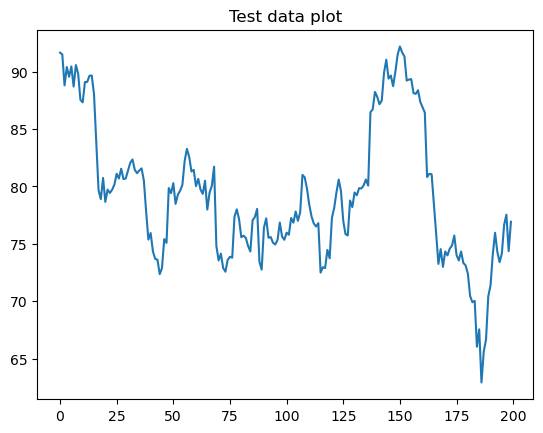

in sequences shape:  (62, 100, 11)
targets shape:  (62, 1)
train loader length:  2
val loader length:  1
Benchmark Celsius: 2.182953769761902
Normalized Benchmark: 0.032343749609498505


In [5]:
train_loader, val_loader, benchmark = generate_loaders_and_benchmark(raw_numpy_data=data_values, 
                                                                     window_step_length=window_step_length,
                                                                     window_size=window_size,
                                                                     num_test_points=num_test_points,
                                                                     horizon=horizon,
                                                                     target_idx=target_idx,
                                                                     minimal_plotting=False
                                                                     )

In [6]:
from train.train_functions import get_device, plot_training, test_model_output
from single_asset_models.CrossAttentionGRUV1 import CrossAttentionGRUV1
from single_asset_models.CrossAttentionGRUV2 import CrossAttentionGRUV2

import deeplay as dl
import torch

In [7]:
device = get_device()
print(device)

cuda:0


In [17]:
cross_attn_gru_v1 = CrossAttentionGRUV1(in_dim=n_features, hidden_dim=144, num_hidden_layers=3, out_dim=1, dropout=0.1, num_heads=24)
cross_attn_gru_v2 = CrossAttentionGRUV2(in_dim=n_features, hidden_dim=144, num_hidden_layers=3, out_dim=1, dropout=0.1, num_heads=24)

In [18]:
gru_dl = dl.RecurrentModel(
    in_features=n_features,
    hidden_features=[128, 128, 128],
    out_features=1,
    rnn_type="GRU",
    dropout=0.2,
)

In [19]:
epochs = 40

In [20]:
chosen_model = gru_dl
print(type(chosen_model))

<class 'deeplay.models.recurrentmodel.RecurrentModel'>


INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | RecurrentModel   | 252 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
252 K     Trainable params
0         Non-trainable params
252 K     Total params
1.010     Total estimated model params size (MB)
23        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

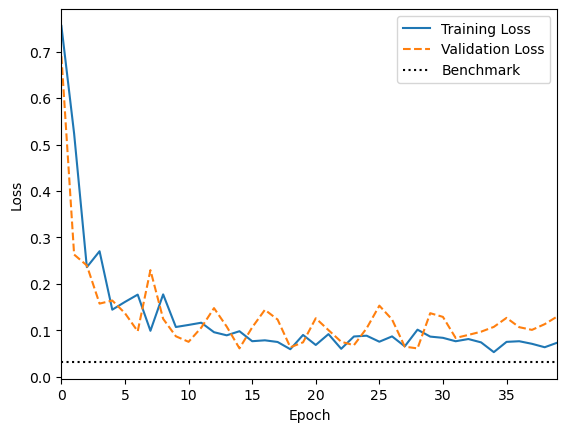

In [21]:
#trained_chosen_model_path = train_model(chosen_model, epochs=epochs, optimizer=, train_loader=train_loader, val_loader=val_loader, benchmark=benchmark)

chosen_model_reg = dl.Regressor(chosen_model, optimizer=dl.Adam(lr=0.001)).create()

trainer = dl.Trainer(max_epochs=epochs, accelerator="auto")
trainer.fit(chosen_model_reg, train_loader, val_loader)
train_losses = trainer.history.history["train_loss_epoch"]["value"]
val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]
plot_training(epochs, train_losses, val_losses, benchmark)

In [22]:
test_model_output(model=chosen_model_reg, data_loader=val_loader, num_tests=10)

Last 10 timesteps (input) and true vs predicted temperature:
Sample 1: Last input temp = -1.04, True = -0.89, Pred = -0.95
Sample 2: Last input temp = 0.30, True = -0.74, Pred = -0.79
Sample 3: Last input temp = -1.13, True = -0.82, Pred = -0.83
Sample 4: Last input temp = -0.07, True = 2.63, Pred = 3.01
Sample 5: Last input temp = -0.27, True = 1.23, Pred = 1.46
Sample 6: Last input temp = 1.13, True = 0.92, Pred = 0.95
Sample 7: Last input temp = -0.33, True = -0.39, Pred = -0.39
Sample 8: Last input temp = 0.76, True = -0.49, Pred = -0.48
Sample 9: Last input temp = -0.03, True = 1.16, Pred = 1.66
Sample 10: Last input temp = -0.22, True = -0.89, Pred = -0.87


last window shape:  torch.Size([100, 11])
test data shape torch.Size([200, 11])


c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_indicators, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[(t)*horizon:(t+1)*horizon-1,:], dtype = torch.float32)


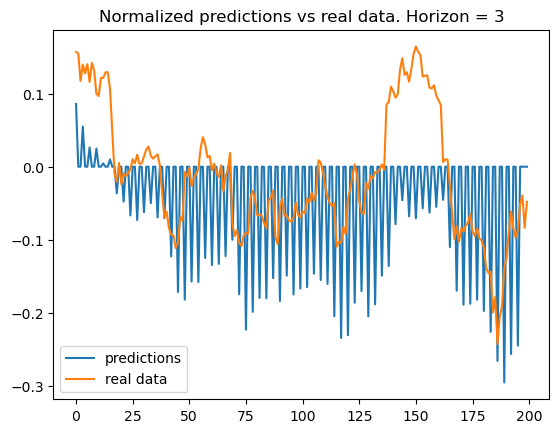

In [23]:
from model_inference.inference_functions import generate_predictions, plot_pred_vs_real

predictions_normalized = generate_predictions(chosen_model_reg, window_step_length, data_values, num_of_future_predictions=num_test_points, horizon=horizon)

plot_pred_vs_real(predictions_normalized, data_values, target_idx, horizon, minimal_plotting=True)

3
variance of returns for old data:  0.001622603062828093
start window shape:  torch.Size([100, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 100, 11])
windows last price:  tensor(89.5000)
period from idx:  0  to idx  3
prediction at 3:  tensor(86.5404)
last price from test data:  89.5
real price 3 steps forward:  tensor(90.4000)
kelly weight:  {tensor(-1.)}
 
x_in shape:  torch.Size([1, 100, 11])
windows last price:  tensor(88.8000)
period from idx:  3  to idx  6
prediction at 3:  tensor(84.3700)
last price from test data:  tensor(88.8000)
real price 3 steps forward:  tensor(88.7000)
kelly weight:  {tensor(-1.)}
 
x_in shape:  torch.Size([1, 100, 11])
windows last price:  tensor(90.4500)
period from idx:  6  to idx  9
prediction at 3:  tensor(82.6739)
last price from test data:  tensor(90.4500)
real price 3 steps forward:  tensor(87.5400)
kelly weight:  {tensor(-1.)}
 
x_in shape:  torch.Size([1, 100, 11])
windows last price:  tensor(89.8300)
period from idx: 

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 100, 11])
windows last price:  tensor(72.7500)
period from idx:  90  to idx  93
prediction at 3:  tensor(65.7450)
last price from test data:  tensor(72.7500)
real price 3 steps forward:  tensor(75.5900)
kelly weight:  {tensor(-1.)}
 
x_in shape:  torch.Size([1, 100, 11])
windows last price:  tensor(75.5300)
period from idx:  93  to idx  96
prediction at 3:  tensor(67.4859)
last price from test data:  tensor(75.5300)
real price 3 steps forward:  tensor(75.3400)
kelly weight:  {tensor(-1.)}
 
x_in shape:  torch.Size([1, 100, 11])
windows last price:  tensor(74.9400)
period from idx:  96  to idx  99
prediction at 3:  tensor(65.9242)
last price from test data:  tensor(74.9400)
real price 3 steps forward:  tensor(75.3500)
kelly weight:  {tensor(-1.)}
 
x_in shape:  torch.Size([1, 100, 11])
windows last price:  tensor(75.6300)
period from idx:  99  to idx  102
prediction at 3:  tensor(67.0706)
last price from test data:  tensor(75.6300)
real price 3 steps forward:

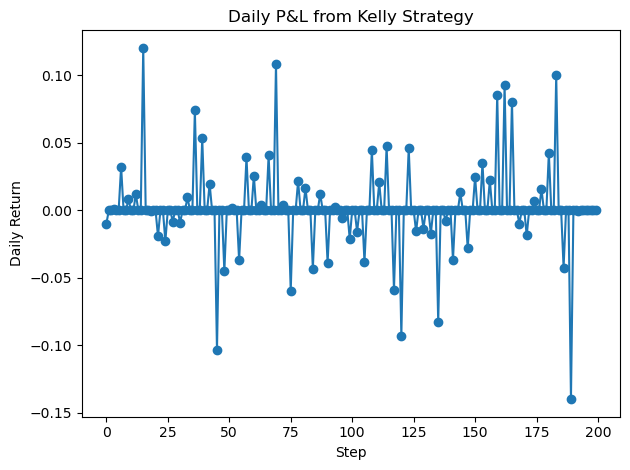

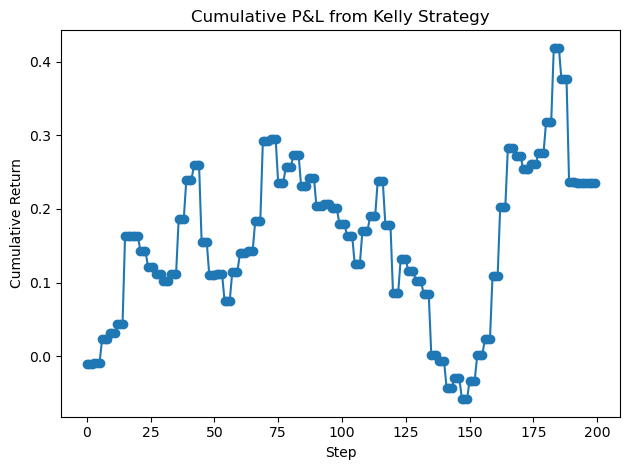

In [24]:
from model_inference.inference_functions import  generate_predictions_and_returns, plot_realized_returns
import matplotlib.pyplot as plt
import numpy as np

print(horizon)
preds_norm, weights, pnl = generate_predictions_and_returns(chosen_model_reg, 
                                                  window_size, 
                                                  data_values, 
                                                  target_idx,
                                                  num_of_future_predictions=num_test_points, 
                                                  horizon=horizon,
                                                  print_values_for_allocation=True)

plot_realized_returns(pnl, plot_only_cumulative=False)

In [25]:
print(weights)
print()
print(pnl)

'''Model version_61 had 0.02 in mae'''

[-1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0.
 -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0.
 -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0.
 -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0.
 -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0.
 -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0.
 -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0.
 -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0.
 -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0.
 -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0.
 -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0. -1.  0.  0.  0.  0.  0.
  0.  0.]

[-0.01005588  0.          0.          0.00112619  0.          0.
  0.03217243  0.          0.          0.0081265   0.          0.
  0.01178578  0.          0.          0.1201205   0.    

'Model version_61 had 0.02 in mae'

Shape dataset (6409, 11)
means:  Close           8.057271e+01
Volume          1.259072e+07
MarketCap       1.279897e+11
Weight          4.173304e-02
Return          6.364129e-04
LogReturn       4.338309e-04
WeightedRet     3.053555e-05
SMA20           8.022321e+01
EMA20           8.021005e+01
RSI14           5.253680e+01
ReturnVola20    1.835859e-02
dtype: float64
stds:  Close           6.781238e+01
Volume          1.708028e+07
MarketCap       1.077200e+11
Weight          1.297622e-02
Return          2.013867e-02
LogReturn       2.012149e-02
WeightedRet     8.541972e-04
SMA20           6.744902e+01
EMA20           6.737596e+01
RSI14           1.213508e+01
ReturnVola20    8.307794e-03
dtype: float64


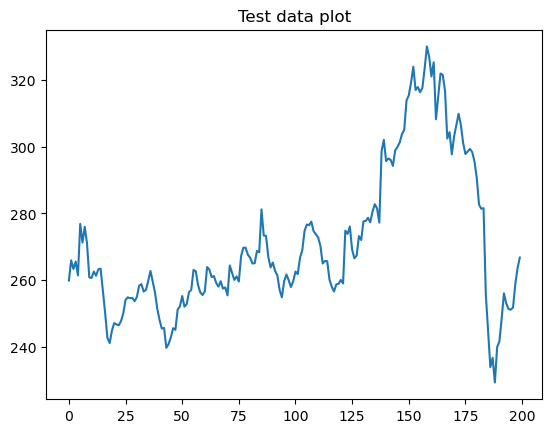

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV2 | 407 K  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
407 K     Trainable params
0         Non-trainable params
407 K     Total params
1.628     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (62, 100, 11)
targets shape:  (62, 1)
train loader length:  2
val loader length:  1
Benchmark Celsius: 1.6983191913994442
Normalized Benchmark: 0.02907880940246743


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

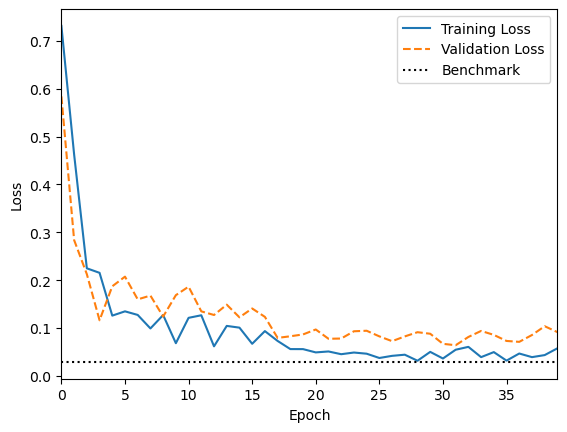

variance of returns for old data:  0.001251027997524831
start window shape:  torch.Size([100, 11])
test data shape torch.Size([200, 11])


c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


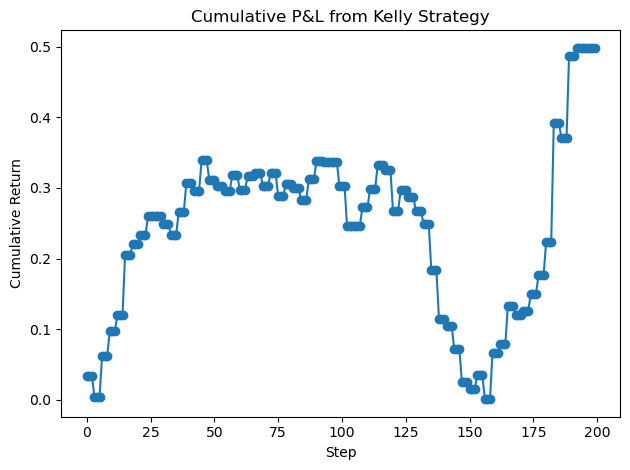

Shape dataset (6409, 11)
means:  Close           8.036797e+01
Volume          1.087093e+06
MarketCap       1.954685e+10
Weight          6.289315e-03
Return          4.417263e-04
LogReturn       1.723115e-04
WeightedRet     4.306955e-06
SMA20           8.029539e+01
EMA20           8.029467e+01
RSI14           5.211280e+01
ReturnVola20    2.049862e-02
dtype: float64
stds:  Close           7.186329e+01
Volume          9.459844e+05
MarketCap       1.747837e+10
Weight          3.087590e-03
Return          2.315582e-02
LogReturn       2.325378e-02
WeightedRet     1.423583e-04
SMA20           7.175884e+01
EMA20           7.168856e+01
RSI14           1.325365e+01
ReturnVola20    1.071267e-02
dtype: float64


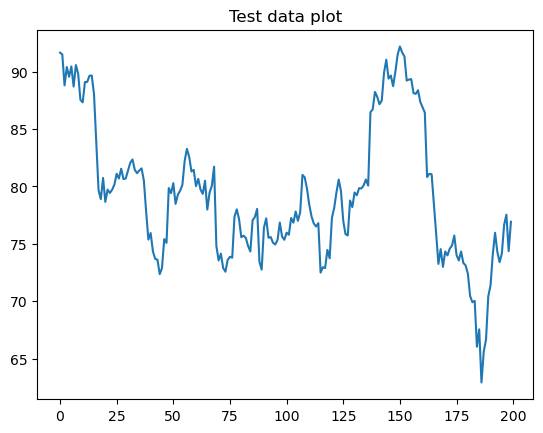

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV2 | 407 K  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
407 K     Trainable params
0         Non-trainable params
407 K     Total params
1.628     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (62, 100, 11)
targets shape:  (62, 1)
train loader length:  2
val loader length:  1
Benchmark Celsius: 2.182953769761902
Normalized Benchmark: 0.03614488512745604


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

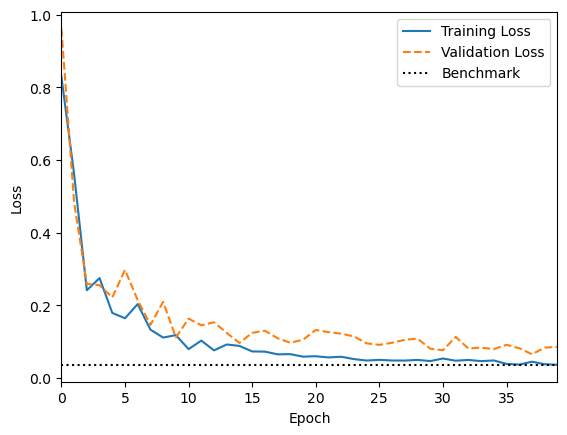

variance of returns for old data:  0.001622603062828093
start window shape:  torch.Size([100, 11])
test data shape torch.Size([200, 11])


c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


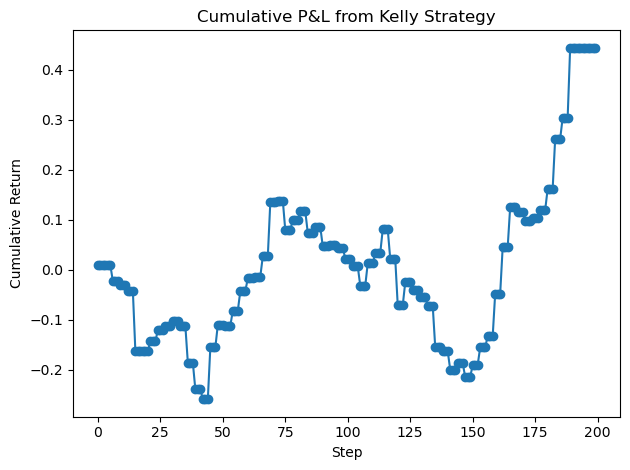

Shape dataset (6409, 11)
means:  Close           5.307977e+01
Volume          2.609046e+06
MarketCap       3.623076e+10
Weight          1.444499e-02
Return          3.644539e-04
LogReturn       1.553114e-04
WeightedRet     7.049176e-06
SMA20           5.295349e+01
EMA20           5.295416e+01
RSI14           5.179019e+01
ReturnVola20    1.809590e-02
dtype: float64
stds:  Close           2.570164e+01
Volume          2.088232e+06
MarketCap       1.754322e+10
Weight          4.131679e-03
Return          2.043817e-02
LogReturn       2.047098e-02
WeightedRet     3.104614e-04
SMA20           2.544732e+01
EMA20           2.542171e+01
RSI14           1.229032e+01
ReturnVola20    9.622688e-03
dtype: float64


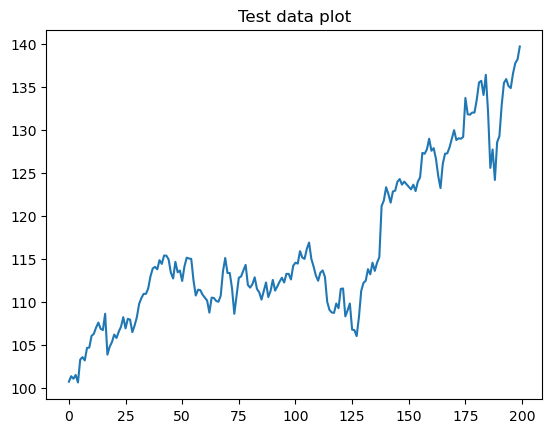

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV2 | 407 K  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
407 K     Trainable params
0         Non-trainable params
407 K     Total params
1.628     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (62, 100, 11)
targets shape:  (62, 1)
train loader length:  2
val loader length:  1
Benchmark Celsius: 1.1280938986613218
Normalized Benchmark: 0.0465732131002985


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

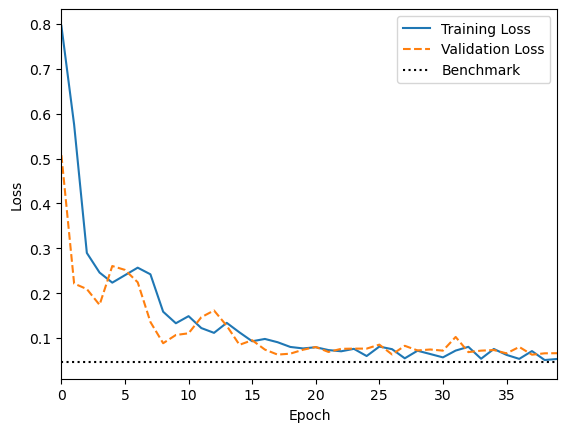

variance of returns for old data:  0.0012777499439489655
start window shape:  torch.Size([100, 11])
test data shape torch.Size([200, 11])


c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


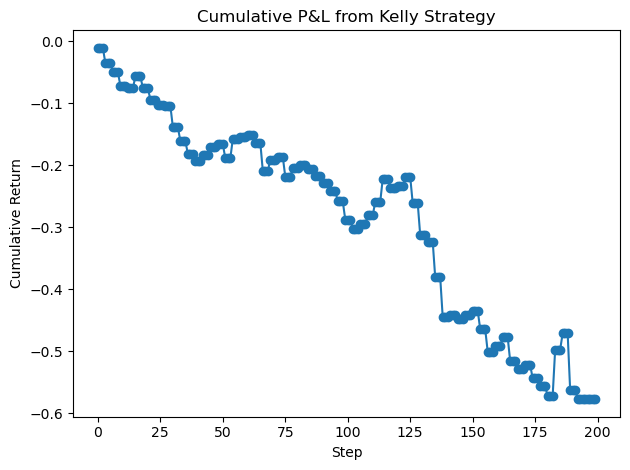

Shape dataset (6409, 11)
means:  Close           4.287665e+01
Volume          1.622439e+07
MarketCap       2.741858e+10
Weight          6.514688e-03
Return          1.013163e-03
LogReturn       8.454286e-04
WeightedRet     5.823438e-06
SMA20           4.268866e+01
EMA20           4.268637e+01
RSI14           5.367379e+01
ReturnVola20    1.646139e-02
dtype: float64
stds:  Close           5.315726e+01
Volume          2.120021e+07
MarketCap       3.399279e+10
Weight          5.999352e-03
Return          1.855441e-02
LogReturn       1.817745e-02
WeightedRet     1.488044e-04
SMA20           5.304622e+01
EMA20           5.302394e+01
RSI14           1.233431e+01
ReturnVola20    8.701578e-03
dtype: float64


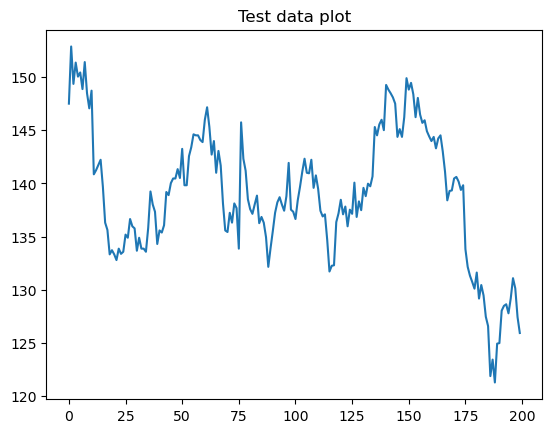

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV2 | 407 K  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
407 K     Trainable params
0         Non-trainable params
407 K     Total params
1.628     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (62, 100, 11)
targets shape:  (62, 1)
train loader length:  2
val loader length:  1
Benchmark Celsius: 0.8300899375149637
Normalized Benchmark: 0.015799551200314066


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

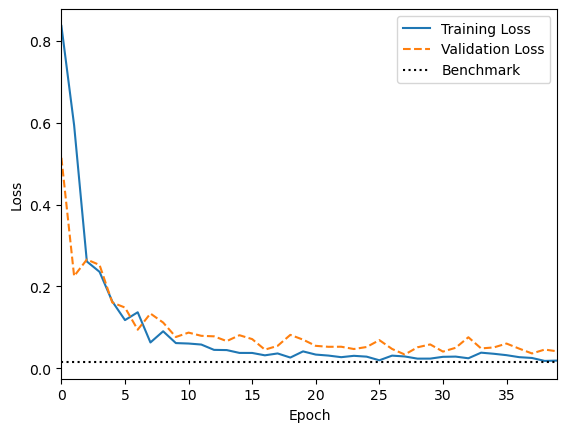

variance of returns for old data:  0.0010424562365118526
start window shape:  torch.Size([100, 11])
test data shape torch.Size([200, 11])


c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


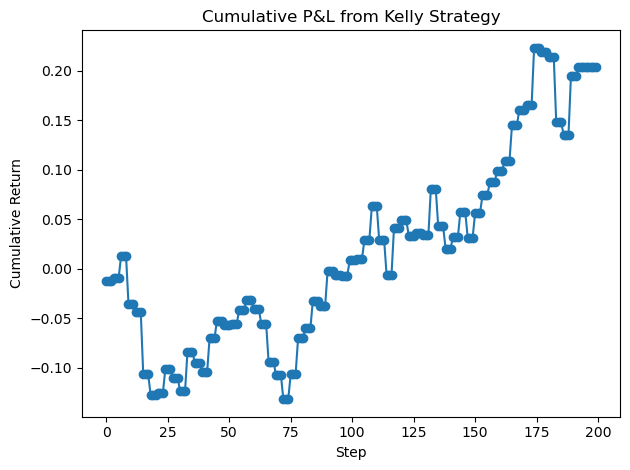

Shape dataset (6409, 11)
means:  Close           8.048078e+01
Volume          3.758859e+06
MarketCap       9.046442e+10
Weight          3.301419e-02
Return          5.541625e-04
LogReturn       3.355078e-04
WeightedRet     1.920720e-05
SMA20           8.019766e+01
EMA20           8.019275e+01
RSI14           5.295434e+01
ReturnVola20    1.746071e-02
dtype: float64
stds:  Close           4.976840e+01
Volume          3.393888e+06
MarketCap       5.594217e+10
Weight          9.042221e-03
Return          2.088719e-02
LogReturn       2.093087e-02
WeightedRet     5.864703e-04
SMA20           4.945678e+01
EMA20           4.941360e+01
RSI14           1.161564e+01
ReturnVola20    1.153466e-02
dtype: float64


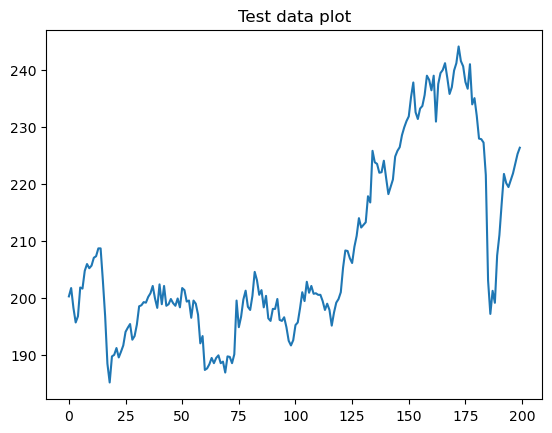

INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV2 | 407 K  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
407 K     Trainable params
0         Non-trainable params
407 K     Total params
1.628     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      |

in sequences shape:  (62, 100, 11)
targets shape:  (62, 1)
train loader length:  2
val loader length:  1
Benchmark Celsius: 1.5399574773986993
Normalized Benchmark: 0.03552456194793497


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

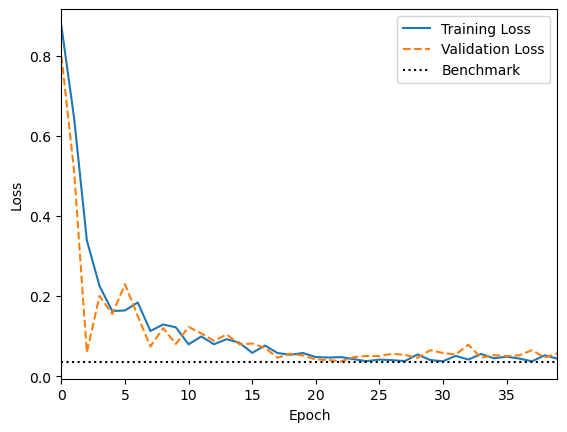

variance of returns for old data:  0.0012893491825127655
start window shape:  torch.Size([100, 11])
test data shape torch.Size([200, 11])


c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


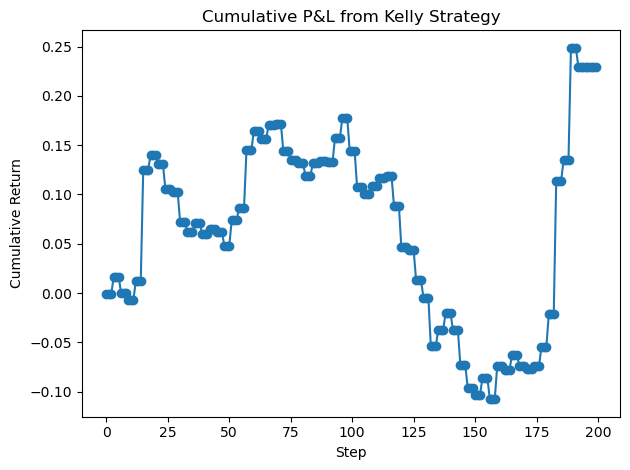

In [32]:
tickers = ['VOLV-B.ST', 'KINV-B.ST', 'TEL2-B.ST', 'SCA-B.ST', 'SWED-A.ST']
epochs = 40
for ticker in tickers:
    data_values, dataframe = retrive_and_extract_relevant_data_values(df=df, feature_cols=feature_cols, chosen_ticker=ticker, no_plotting=True)

    train_loader, val_loader, benchmark = generate_loaders_and_benchmark(raw_numpy_data=data_values, 
                                                                     window_step_length=window_step_length,
                                                                     window_size=window_size,
                                                                     num_test_points=num_test_points,
                                                                     horizon=horizon,
                                                                     target_idx=target_idx,
                                                                     minimal_plotting=False
                                                                     )
    cross_attn_gru_v2 = CrossAttentionGRUV2(in_dim=n_features, hidden_dim=144, num_hidden_layers=3, out_dim=1, dropout=0.1, num_heads=24)
    #trained_chosen_model_path = train_model(chosen_model, epochs=epochs, optimizer=, train_loader=train_loader, val_loader=val_loader, benchmark=benchmark)
    chosen_model = cross_attn_gru_v2
    chosen_model_reg = dl.Regressor(chosen_model, optimizer=dl.Adam(lr=0.001)).create()

    trainer = dl.Trainer(max_epochs=epochs, accelerator="auto")
    trainer.fit(chosen_model_reg, train_loader, val_loader)
    train_losses = trainer.history.history["train_loss_epoch"]["value"]
    val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]
    plot_training(epochs, train_losses, val_losses, benchmark)
    preds_norm, weights, pnl = generate_predictions_and_returns(chosen_model_reg, 
                                                  window_size, 
                                                  data_values, 
                                                  target_idx,
                                                  num_of_future_predictions=num_test_points, 
                                                  horizon=horizon,
                                                  print_values_for_allocation=False)

    plot_realized_returns(pnl, plot_only_cumulative=True)